In [54]:
import pandas as pd
import pickle
import os
import re
def load_dict(name ):
    with open(name, 'rb') as f:
        return pickle.load(f)
def read_df():
    path = './data/'
    for root,dirs,files in os.walk(path):
        for file in files:
            filepath = os.path.join(root,file)
            if file.endswith('res.pkl'):
                yield load_dict(filepath)
res = list(read_df())
res_df = pd.DataFrame(res)

In [55]:
Metric_df = pd.read_csv('./Metric_new.csv')

In [56]:
Metric_df.fillna(0,inplace=True)

In [57]:
Metric_df['basic_DataFlux'] = Metric_df['basic_DataFlux'].apply(lambda x: int(x) if int(x) <= 2**20 else 2**20)
Metric_df['latency_DataFlux'] = Metric_df['latency_DataFlux'].apply(lambda x: int(x) if int(x) <= 2**20 else 2**20)
Metric_df['error_DataFlux'] = Metric_df['error_DataFlux'].apply(lambda x: int(x) if int(x) <= 2**20 else 2**20)

In [58]:
Me_df= Metric_df.fillna(0).groupby(by=['name','qpu_width']).sum()

In [59]:
Me_df.reset_index(inplace=True)

In [60]:
res_df= res_df[['name','width', 'depth', 'two_qubit_gate_num',
       'one_qubit_gate_num', 'size', 'qubit_utilizztion', 'fidelity',
       'latency_all']]

In [61]:
res_df['size'].max()

9875

In [62]:
df =  pd.merge(Me_df, res_df, on='name')
df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj_indep_qiskit_103,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj_indep_qiskit_103,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj_indep_qiskit_103,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj_indep_qiskit_109,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.000002,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054
4,dj_indep_qiskit_109,36,3.0,4.0,40.0,0.000017,0.872981,0.000011,0.084973,3.0,...,0.000002,0.113065,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,wstate_nativegates_ibm_qiskit_opt3_93,50,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,...,0.000029,0.291252,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate_nativegates_ibm_qiskit_opt3_93,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate_nativegates_ibm_qiskit_opt3_97,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate_nativegates_ibm_qiskit_opt3_97,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


In [63]:
df = df[df['qpu_width']< df['width']]
df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj_indep_qiskit_103,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj_indep_qiskit_103,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj_indep_qiskit_103,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj_indep_qiskit_109,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.000002,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054
4,dj_indep_qiskit_109,36,3.0,4.0,40.0,0.000017,0.872981,0.000011,0.084973,3.0,...,0.000002,0.113065,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,wstate_nativegates_ibm_qiskit_opt3_93,50,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,...,0.000029,0.291252,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate_nativegates_ibm_qiskit_opt3_93,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate_nativegates_ibm_qiskit_opt3_97,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate_nativegates_ibm_qiskit_opt3_97,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


In [64]:
df = df[df['qpu_width'].isin([5,10,16,27,50,65])]

In [65]:
df.drop(['latency_num_cuts', 'latency_subcircuits_num',
       'latency_DataFlux', 'latency_Latency', 'latency_Fidelity'],axis=1).to_csv('dataLatency.csv',index=False)

In [66]:
df.columns

Index(['name', 'qpu_width', 'mip_num_cuts', 'mip_subcircuits_num',
       'mip_DataFlux', 'mip_Latency', 'mip_Fidelity', 'mip_min_latency',
       'mip_QU', 'basic_num_cuts', 'basic_subcircuits_num', 'basic_DataFlux',
       'basic_Latency', 'basic_Fidelity', 'basic_min_latency', 'basic_QU',
       'error_num_cuts', 'error_subcircuits_num', 'error_DataFlux',
       'error_Latency', 'error_Fidelity', 'error_min_latency', 'error_QU',
       'latency_num_cuts', 'latency_subcircuits_num', 'latency_DataFlux',
       'latency_Latency', 'latency_Fidelity', 'latency_min_latency',
       'latency_QU', 'width', 'depth', 'two_qubit_gate_num',
       'one_qubit_gate_num', 'size', 'qubit_utilizztion', 'fidelity',
       'latency_all'],
      dtype='object')

In [67]:
df['name'] = df['name'].str.replace('\d+', '')
df['name'] = df['name'].str.replace('_nativegates_ibm_qiskit_opt3_', '')
df['name'] = df['name'].str.replace('_nativegates_ibm_qiskit_opt_', '')
df['name'] = df['name'].str.replace('_indep_qiskit_', '')

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/3851312542.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df['name'] = df['name'].str.replace('\d+', '')
/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/3851312542.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['name'] = df['name'].str.replace('\d+', '')
/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/3851312542.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

In [68]:
df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.000002,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054
7,dj,50,2.0,3.0,24.0,0.000021,0.873850,0.000014,0.149187,2.0,...,0.000005,0.162900,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,wstate,50,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,...,0.000029,0.291252,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


In [76]:
main_df= df[df.name.isin(df.name.value_counts()[:11].index.to_list())]

In [77]:
main_df


,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.000002,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054
7,dj,50,2.0,3.0,24.0,0.000021,0.873850,0.000014,0.149187,2.0,...,0.000005,0.162900,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,wstate,50,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,...,0.000029,0.291252,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


In [78]:
df = main_df


In [71]:
df.to_csv('data.csv',index=False)

In [72]:
def group_by_qpu_width(df, qpu_width):
    grouped = df.groupby('qpu_width')
    return grouped.get_group(qpu_width)
def group_by_name(df, name):
    grouped = df.groupby('name')
    return grouped.get_group(name)

## 统计在限定时间内无法切割的benchmark 实例比例

In [30]:

mip_nums = []
basic_nums = []
names = []
for name,group in df.groupby('name'):
    ## 计算无法切割实例的比例
    mip_nums.append(len(group[group['mip_num_cuts']>0]))
    basic_nums.append(len(group))
    names.append(name)

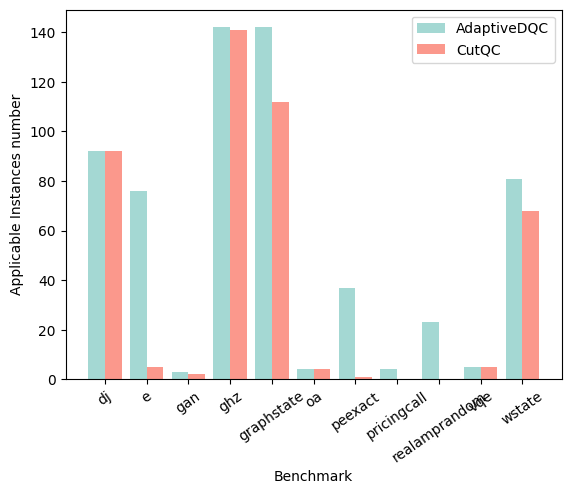

In [59]:
import matplotlib.pyplot as plt
import numpy as np
# 绘制柱状图

bar_width = 0.4
fig, ax = plt.subplots()
ax.bar(names, basic_nums, label='adaptivedqc', color=colours[0], alpha=0.8, width=0.4)
ax.bar(np.arange(len(names)) + bar_width, mip_nums, label='CutQC', color=colours[2], alpha=0.8, width=0.4)
# 添加标签和标题
ax.set_xticks(np.arange(len(names)) + bar_width / 2)
ax.set_xticklabels(names,rotation=35)
ax.set_xlabel('Benchmark')
ax.set_ylabel('Applicable Instances number')
ax.legend()
# 显示图形
plt.show()


### 绘制cutnumber 对比图

In [44]:
cutN = df[['width','qpu_width','name','mip_num_cuts','basic_num_cuts','mip_subcircuits_num','basic_subcircuits_num']][df['basic_num_cuts']>0].sort_values(by='width')

<Figure size 1200x800 with 0 Axes>

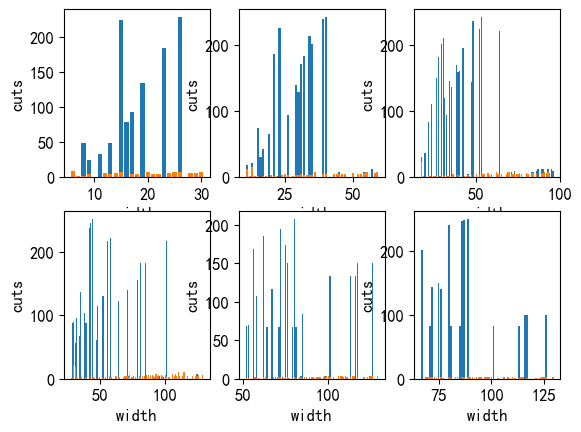

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size']=12
fig, axes = plt.subplots(nrows=2, ncols=3)
QPU_list = cutN['qpu_width'].unique().reshape(2,3)
for i in range(2):
    for j in range(3):
        data = cutN[cutN['qpu_width']==QPU_list[i][j]]
        for name,group in data.groupby('name'):
            axes[i][j].plot(group['width'],group['basic_num_cuts'],label=name+' adaptivedqc')
            axes[i][j].scatter(group['width'],group['mip_num_cuts'],label=name+' mip')
            axes[i][j].set_xlabel('width')
            axes[i][j].set_ylabel('cuts')

In [130]:
colours = ['#8ECFC9',
           "#FFBE7A",
"#FA7F6F",
"#82B0D2",
"#BEB8DC",
"#E7DAD2"]

Text(0.5, 1.0, 'cut number mip vs cluster')

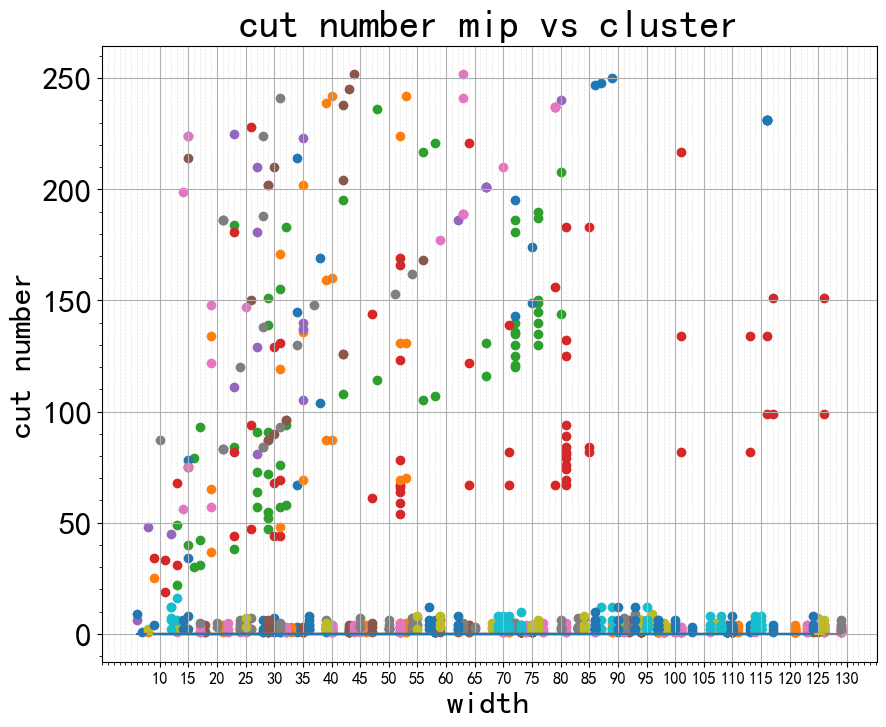

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size']=24
names = cutN['name'].value_counts().index[cutN['name'].value_counts()>2].to_list()
for name,group in cutN.groupby('name'):
    if name not in names:
        continue
    plt.scatter(group['width'],group['basic_num_cuts'],label=name+' cluster')
    plt.plot(group['width'],group['mip_num_cuts'],label=name+' mip')
import numpy as np 
# plt.ylim(top=30,bottom=0)
# plt.scatter(cutN['width'],cutN['basic_num_cuts'],c='green',marker='*',alpha = 0.3,label= 'cluster')
# plt.scatter(cutN['width'],cutN['mip_num_cuts'],c='red',marker='.',alpha = 0.3,label= 'mip')
# plt.ylim(top=13,bottom=0)
plt.grid(visible=True)
plt.xticks(np.arange(10, 131, 5),fontsize=12)
plt.grid(axis='x', which='minor', linestyle='--',
         linewidth=0.5, color='gray', alpha=0.2)
plt.minorticks_on()
plt.xlabel('width')
plt.ylabel('cut number')
plt.title('cut number mip vs cluster')
# plt.legend(fontsize=12)
# plt.savefig('../imgs/cut_number_mip_vs_cluster.png',dpi=600)

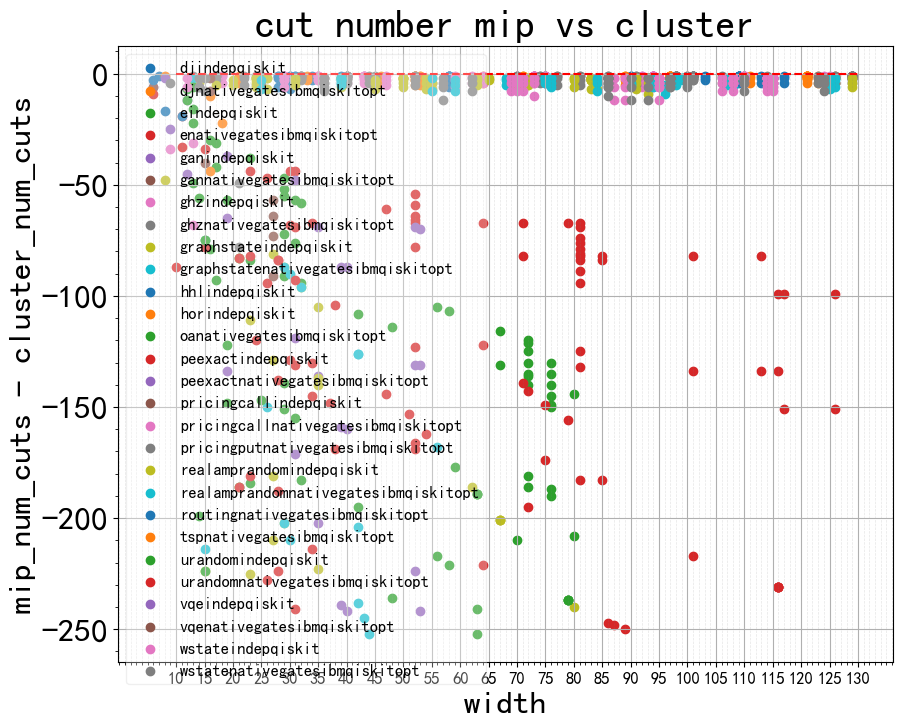

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 24
# plt.rcParams['legend.face.alpha'] = 0.5
names = cutN['name'].value_counts(
).index[cutN['name'].value_counts() > 0].to_list()
for name, group in cutN.groupby('name'):
    if name not in names:
        continue
    plt.scatter(group['width'], group['mip_num_cuts']- group['basic_num_cuts'],
                label=name)
# plt.scatter(cutN['width'],cutN['basic_num_cuts'],c='green',marker='*',alpha = 0.3,label= 'cluster')
# plt.scatter(cutN['width'],cutN['mip_num_cuts'],c='red',marker='.',alpha = 0.3,label= 'mip')
# plt.ylim(top=4, bottom=-1)
plt.grid(visible=True)
plt.xticks(np.arange(10, 131, 5), fontsize=12)
plt.hlines(0,10,130,colors='red', linestyles='dashed')
plt.grid(axis='x', which='minor', linestyle='--',
         linewidth=0.5, color='gray', alpha=0.2)
plt.minorticks_on()
plt.xlabel('width')
plt.ylabel('mip_num_cuts - cluster_num_cuts')
plt.title('cut number mip vs cluster')
plt.legend(fontsize=12, framealpha=0.3)
# plt.savefig('../imgs/cut_number_mip-cluster.png',dpi=600)


## 绘制subcircuits_Num

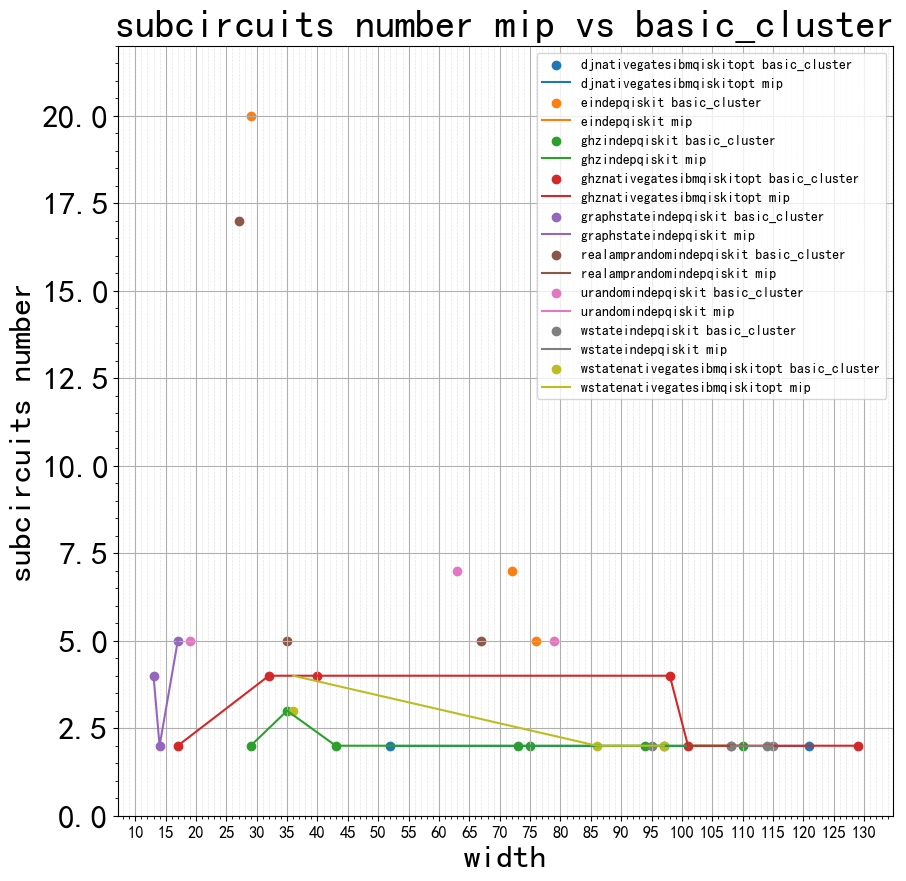

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
names = cutN['name'].value_counts().index[cutN['name'].value_counts()>2].to_list()
for name,group in cutN.groupby('name'):
    if name not in names:
        continue
    plt.scatter(group['width'],group['basic_subcircuits_num'],label=name+' cluster')
    plt.plot(group['width'],group['mip_subcircuits_num'],label=name+' mip')

plt.ylim(top=22,bottom=0)
plt.grid(visible=True)
plt.xticks(np.arange(10, 131, 5), fontsize=12)
plt.grid(axis='x', which='minor', linestyle='--',
         linewidth=0.5, color='gray', alpha=0.2)
plt.minorticks_on()
plt.xlabel('width')
plt.ylabel('subcircuits number')
plt.title('subcircuits number mip vs cluster')
plt.legend(fontsize=10)
plt.savefig('../imgs/subcircuits_number.png',dpi=600)

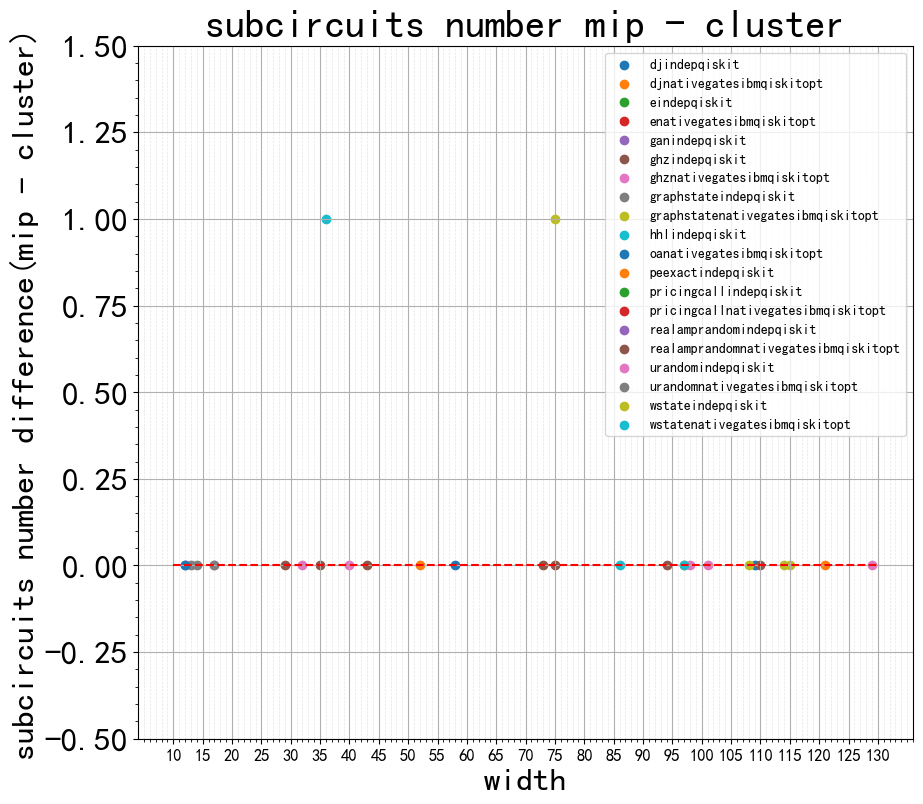

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,9))
names = cutN['name'].value_counts().index[cutN['name'].value_counts()>0].to_list()
for name,group in cutN.groupby('name'):
    if name not in names:
        continue
    plt.scatter(group['width'],group['mip_subcircuits_num'] -group['basic_subcircuits_num'],label=name)
plt.ylim(top=1.5,bottom=-0.5)
plt.grid(visible=True)
plt.hlines(0,10,130,colors='red', linestyles='dashed')
plt.xticks(np.arange(10, 131, 5), fontsize=12)
plt.grid(axis='x', which='minor', linestyle='--',
         linewidth=0.5, color='gray', alpha=0.2)
plt.minorticks_on()
plt.xlabel('width')
plt.ylabel('subcircuits number difference(mip - cluster)')
plt.title('subcircuits number mip - cluster')
plt.legend(fontsize=10)
plt.savefig('../imgs/subcircuits_number_diff.png',dpi=600)

In [ ]:
df['mip_DataFlux'].describe()

count    1.057000e+03
mean     1.671259e+10
std      5.411080e+11
min      0.000000e+00
25%      0.000000e+00
50%      8.000000e+00
75%      4.000000e+01
max      1.759219e+13
Name: mip_DataFlux, dtype: float64

## 指标分析

In [164]:
valid_df = df[df['width']> df['qpu_width']]

In [111]:
df.name.value_counts()

ghz              142
graphstate       142
dj                92
wstate            81
peexact           37
realamprandom     23
vqe                5
oa                 4
pricingcall        4
gan                3
Name: name, dtype: int64

In [123]:
df = df[(df['name']!='oa') & (df['name']!='e')]

In [114]:
df['Adaptive_DataFlux'] = df[['basic_DataFlux','latency_DataFlux','error_DataFlux']].apply(min, axis=1)

In [210]:
valid_df = df[df['mip_DataFlux']>0]

In [116]:
data_DataFlux = valid_df.groupby(by=['name','qpu_width']).mean()[['mip_DataFlux','Adaptive_DataFlux']]
data_DataFlux['ratio'] = data_DataFlux['Adaptive_DataFlux']/data_DataFlux['mip_DataFlux']*100

In [117]:
data_DataFlux.reset_index(inplace=True)

In [118]:
DataFluxTab= data_DataFlux.pivot(index='qpu_width',columns='name',values='ratio')

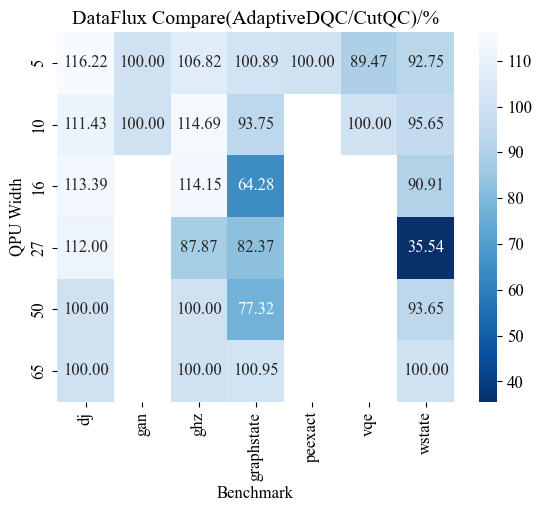

In [119]:
import pandas as pd
import seaborn as sns
plt.rc('font',family='Times New Roman',size=12)
# 使用Seaborn的heatmap()函数绘制热力图，并在每个单元格中显示数值
sns.heatmap(DataFluxTab, annot=True, fmt=".2f",cmap='Blues_r')
# 设置坐标轴标签
plt.xlabel("Benchmark")
plt.ylabel("QPU Width")
plt.title('DataFlux Compare(adaptivedqc/CutQC)/%')
# 显示图形
plt.show()


In [211]:
valid_df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,basic_num_cuts,basic_subcircuits_num,basic_DataFlux,...,latency_Latency,latency_Fidelity,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,3.0,4.0,40,...,0.000013,0.879399,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,2.0,3.0,24,...,0.000025,0.880269,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,1.0,2.0,8,...,0.000032,0.881147,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj,27,4.0,5.0,40.0,0.000013,0.872110,4.0,5.0,52,...,0.000013,0.872109,109,110,108,217,325,0.039513,0.976452,0.000054
7,dj,50,2.0,3.0,24.0,0.000021,0.873850,2.0,3.0,24,...,0.000025,0.873846,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,wstate,27,8.0,5.0,272.0,0.000017,0.866416,6.0,4.0,256,...,0.000017,0.868152,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate,65,2.0,2.0,32.0,0.000033,0.871633,2.0,2.0,32,...,0.000042,0.871633,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate,27,6.0,4.0,272.0,0.000017,0.863094,6.0,4.0,256,...,0.000017,0.863094,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate,50,2.0,2.0,32.0,0.000032,0.866555,2.0,2.0,32,...,0.000032,0.866555,97,388,192,577,769,0.069015,0.956782,0.000063


In [212]:
valid_df.drop_duplicates(subset=['name','width','qpu_width'],inplace=True)

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_2337/283053627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df.drop_duplicates(subset=['name','width','qpu_width'],inplace=True)


In [213]:
valid_df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,basic_num_cuts,basic_subcircuits_num,basic_DataFlux,...,latency_Latency,latency_Fidelity,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,3.0,4.0,40,...,0.000013,0.879399,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,2.0,3.0,24,...,0.000025,0.880269,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,1.0,2.0,8,...,0.000032,0.881147,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj,27,4.0,5.0,40.0,0.000013,0.872110,4.0,5.0,52,...,0.000013,0.872109,109,110,108,217,325,0.039513,0.976452,0.000054
7,dj,50,2.0,3.0,24.0,0.000021,0.873850,2.0,3.0,24,...,0.000025,0.873846,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,wstate,27,8.0,5.0,272.0,0.000017,0.866416,6.0,4.0,256,...,0.000017,0.868152,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate,65,2.0,2.0,32.0,0.000033,0.871633,2.0,2.0,32,...,0.000042,0.871633,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate,27,6.0,4.0,272.0,0.000017,0.863094,6.0,4.0,256,...,0.000017,0.863094,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate,50,2.0,2.0,32.0,0.000032,0.866555,2.0,2.0,32,...,0.000032,0.866555,97,388,192,577,769,0.069015,0.956782,0.000063


/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_2337/1314983166.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['Adaptive_DataFlux'] = valid_df[['basic_DataFlux','latency_DataFlux','error_DataFlux']].apply(min, axis=1)
/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_2337/1314983166.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['ratio'] = (1-valid_df['Adaptive_DataFlux']/valid_df['mip_DataFlux'])*100


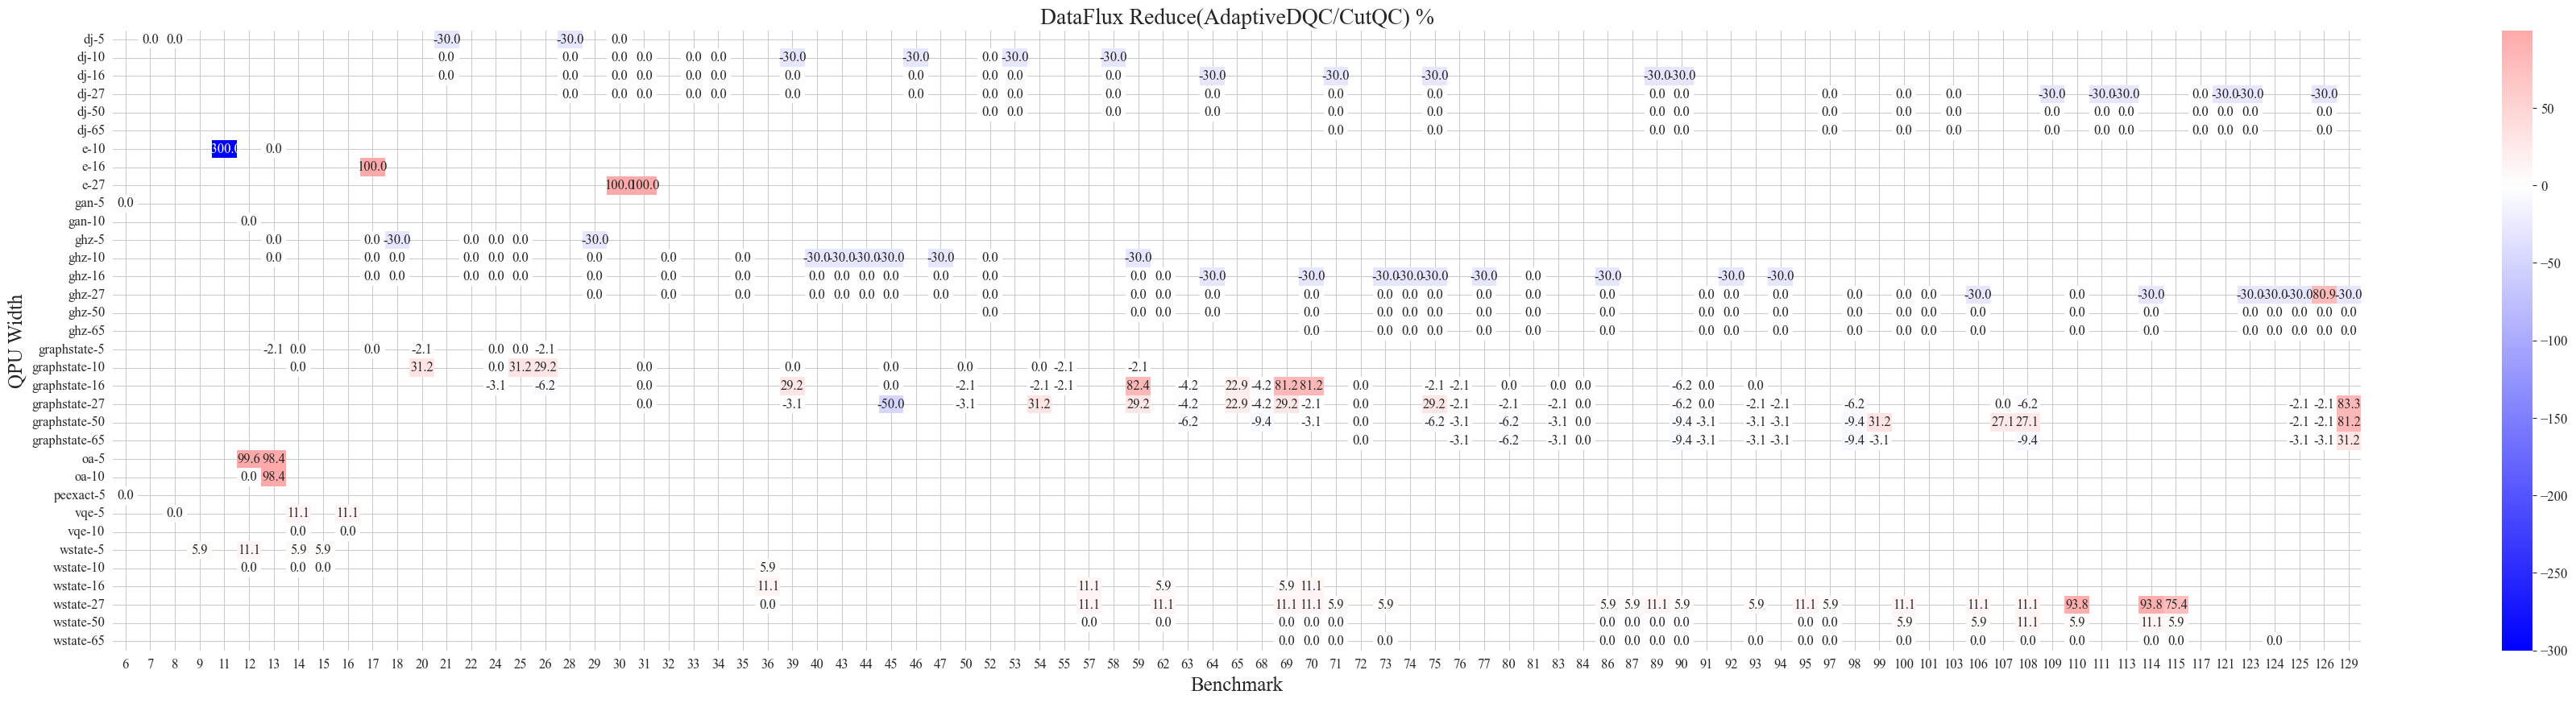

In [216]:
## 用热力图绘制
import seaborn as sns
import pandas as pd
plt.rc('font', family='Times New Roman', size=12)
## 大小设置
plt.figure(figsize=(45, 10))
# 使用Seaborn的heatmap()函数绘制热力图，并在每个单元格中显示数值
valid_df['Adaptive_DataFlux'] = valid_df[['basic_DataFlux','latency_DataFlux','error_DataFlux']].apply(min, axis=1)
valid_df['ratio'] = (1-valid_df['Adaptive_DataFlux']/valid_df['mip_DataFlux'])*100
sns.heatmap(valid_df.pivot(index=['name', 'qpu_width'], columns='width',
            values='ratio'), annot=True, fmt=".1f", cmap='bwr', center=0)
# 设置坐标轴标签
plt.xlabel("Benchmark", fontsize=18)
plt.ylabel("QPU Width", fontsize=18)
plt.title('DataFlux Reduce(adaptivedqc/CutQC) %', fontsize=20)
# 显示图形
plt.show()


## latency

In [142]:
import seaborn as sns
import pandas as pd
valid_df['Adaptive_Latency'] = valid_df[['basic_Latency','latency_Latency','error_Latency']].apply(min, axis=1)
data_Latency = valid_df.groupby(by=['name', 'qpu_width']).mean()[
    ['mip_Latency', 'Adaptive_Latency']]
data_Latency['ratio'] = data_Latency['Adaptive_Latency'] / \
    data_Latency['mip_Latency']*100
data_Latency.reset_index(inplace=True)
latencyTab = data_Latency.pivot(
    index='qpu_width', columns='name', values='ratio')
plt.rc('font', family='Times New Roman', size=12)
# 使用Seaborn的heatmap()函数绘制热力图，并在每个单元格中显示数值
sns.heatmap(latencyTab, annot=True, fmt=".2f", cmap='Blues_r')
# 设置坐标轴标签
plt.xlabel("Benchmark")
plt.ylabel("QPU Width")
plt.title('Latency Compare(adaptivedqc/CutQC)/%')
# 显示图形
plt.show()


## Fidelity

In [85]:
Fidelity_df = valid_df[['name','qpu_width','width','two_qubit_gate_num','fidelity','basic_Fidelity','error_Fidelity','mip_Fidelity']]

In [86]:
Fidelity_df['Adaptive_Fidelity'] = Fidelity_df[['basic_Fidelity','error_Fidelity','mip_Fidelity']].apply(max, axis=1)

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/2507153079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fidelity_df['Adaptive_Fidelity'] = Fidelity_df[['basic_Fidelity','error_Fidelity','mip_Fidelity']].apply(max, axis=1)


In [87]:
Fidelity_df['Adaptive_Error'] = 1-Fidelity_df['Adaptive_Fidelity']
Fidelity_df['mip_Error'] = 1-Fidelity_df['mip_Fidelity']

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/733360096.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fidelity_df['Adaptive_Error'] = 1-Fidelity_df['Adaptive_Fidelity']
/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/733360096.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fidelity_df['mip_Error'] = 1-Fidelity_df['mip_Fidelity']


In [88]:
Fidelity_df.drop_duplicates(['name','qpu_width','width'],inplace=True)


/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/1266318806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fidelity_df.drop_duplicates(['name','qpu_width','width'],inplace=True)


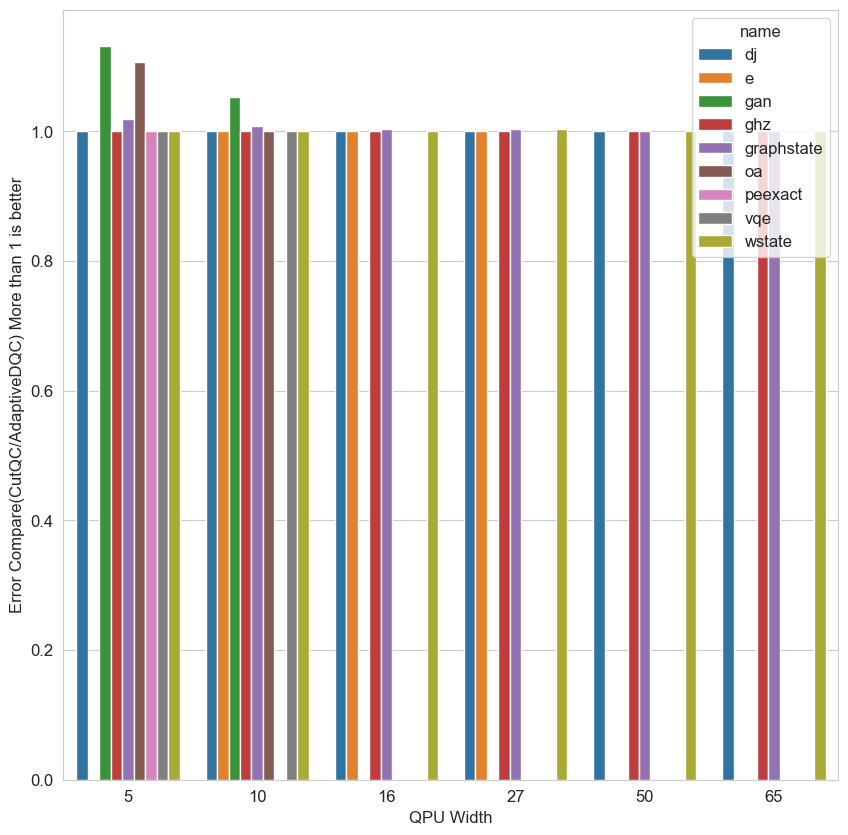

In [92]:
## 按照name和qpu_width分组 绘制mip_fidelity 和 Adaptive_fidelity 的比较柱形图
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
plt.rc('font', family='Times New Roman', size=12)
# 设置绘图风格
sns.set_style("whitegrid")
# 设置绘图大小
plt.figure(figsize=(10, 10))
# 设置绘图数据
data = Fidelity_df.groupby(by=['name', 'qpu_width']).mean()[
    ['mip_Error', 'Adaptive_Error']]
data['Error_ratio'] = data['mip_Error']/data['Adaptive_Error']
data.reset_index(inplace=True)
# 绘制柱形图
sns.barplot(x='qpu_width', y='Error_ratio', hue='name', data=data)
# 设置坐标轴标签
plt.xlabel("QPU Width")
plt.ylabel("Error Compare(CutQC/adaptivedqc) More than 1 is better")
# 显示图形
plt.show()

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/542829294.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fidelity_df['error_Error'] = 1-Fidelity_df['error_Fidelity']
/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/542829294.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fidelity_df['Error_ratio'] = (Fidelity_df['mip_Error']/Fidelity_df['Adaptive_Error']-1)*100


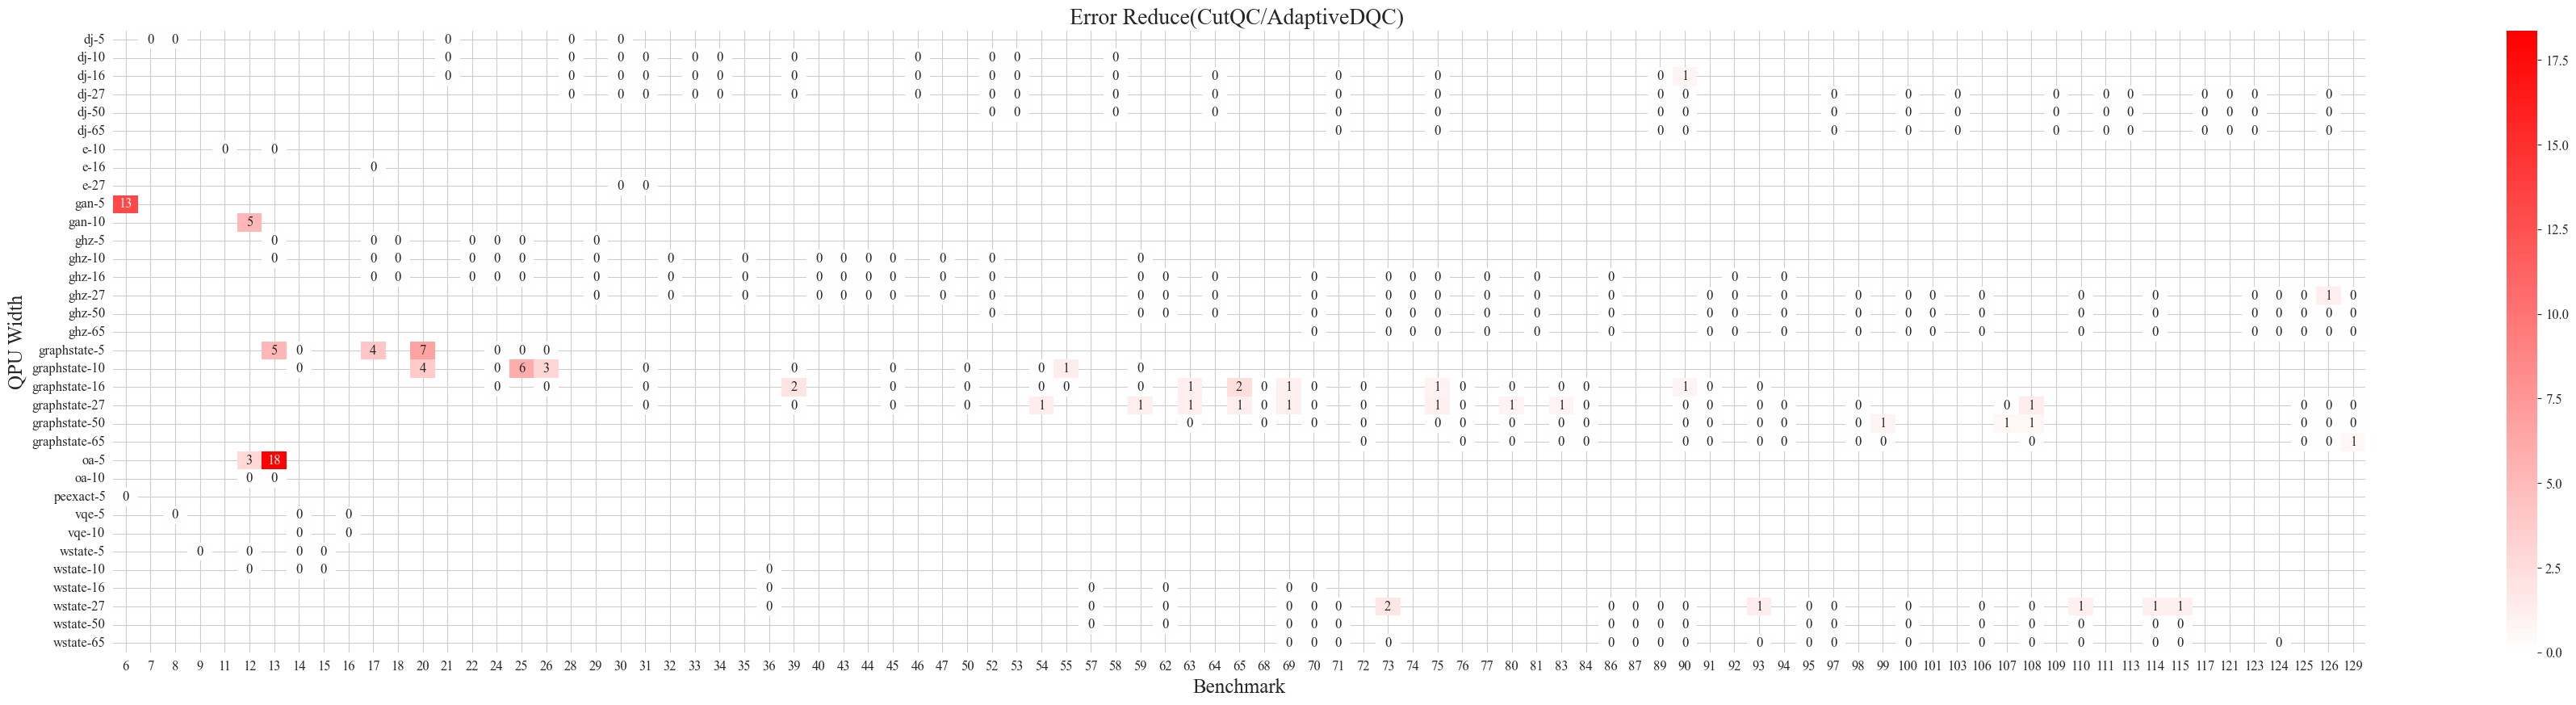

In [99]:
## 用热力图绘制 
import seaborn as sns
import pandas as pd
plt.rc('font', family='Times New Roman', size=12)
## 大小设置
plt.figure(figsize=(45, 10))
Fidelity_df['error_Error'] = 1-Fidelity_df['error_Fidelity']
Fidelity_df['Error_ratio'] = (Fidelity_df['mip_Error']/Fidelity_df['Adaptive_Error']-1)*100
# 使用Seaborn的heatmap()函数绘制热力图，并在每个单元格中显示数值
sns.heatmap(Fidelity_df.pivot(index=['name','qpu_width'], columns='width', values='Error_ratio'), annot=True, fmt=".0f", cmap='bwr',center=0)
# 设置坐标轴标签
plt.xlabel("Benchmark",fontsize=18)
plt.ylabel("QPU Width",fontsize=18)
plt.title('Error Reduce(CutQC/adaptivedqc) ',fontsize=20)
# 显示图形
plt.show()


Text(0.5, 1.0, 'Fidelity Metric Adaptive vs mip')

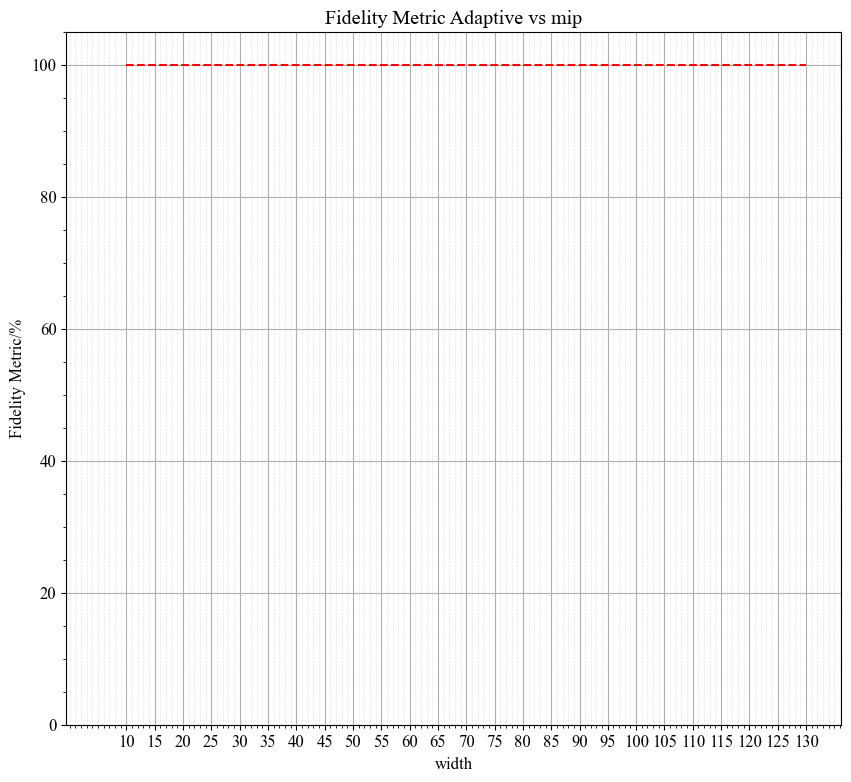

In [136]:
# error compare
## Latency Metric compare
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10,9))
names = valid_df['name'].value_counts(
).index[valid_df['name'].value_counts() > 0].to_list()
colors = plt.cm.rainbow(np.linspace(0, 1, len(names)))
i=0
for name,group in valid_df.groupby('name'):
    if name not in names:
        continue
    plt.bar(group['width'],group['error_Fidelity']*100,color=colors[0],label=name+" adaptivedqc")
    plt.bar(group['width'],group['mip_Fidelity']*100,color=colors[1],label=name+" mip",alpha=0.2)
    i+=1
plt.grid(visible=True)
plt.hlines(100,10,130,colors='red', linestyles='dashed')
plt.xticks(np.arange(10, 131, 5), fontsize=12)
plt.grid(axis='x', which='minor', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.2)
plt.minorticks_on()
plt.xlabel('width')
plt.ylabel('Fidelity Metric/%')
plt.title('Fidelity Metric Adaptive vs mip')
# plt.legend(fontsize=10)
# plt.savefig('../imgs/Fidelity_metric.png',dpi=600)

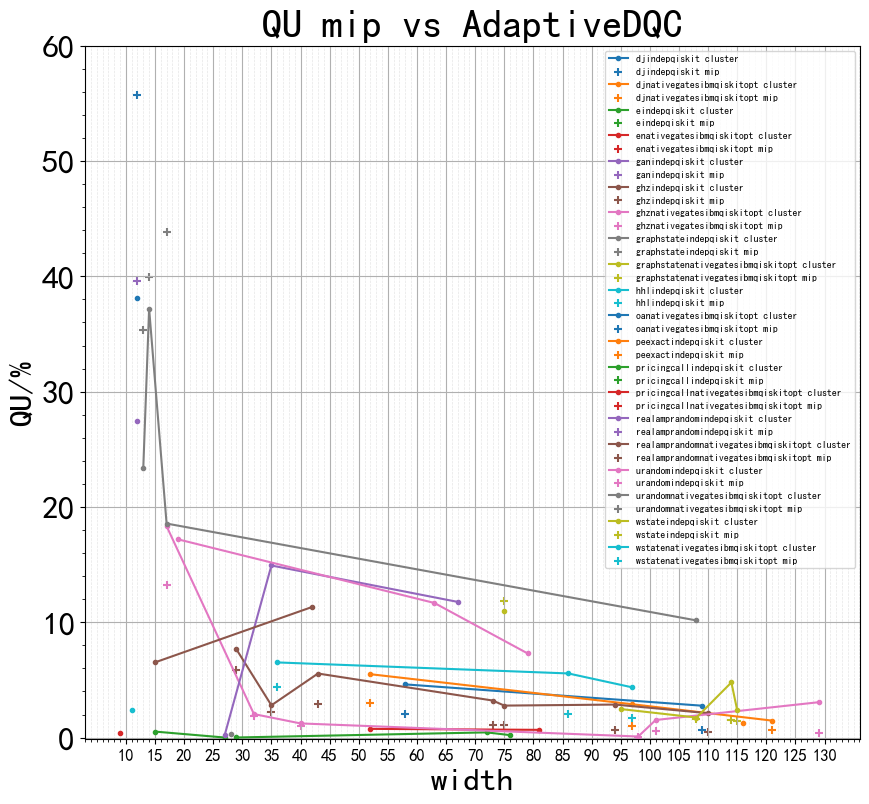

In [ ]:
## QU Metric compare
# valid_df['Latency_ratio'] = valid_df['latency_Latency']/valid_df['mip_Latency']
import matplotlib.pyplot as plt
plt.figure(figsize=(10,9))
names = valid_df['name'].value_counts().index[valid_df['name'].value_counts()>0].to_list()
for name,group in valid_df.groupby('name'):
    if name not in names:
        continue
    plt.plot(group['width'],group['basic_QU']*100,marker='.',label=name+" cluster")
    plt.scatter(group['width'],group['mip_QU']*100,marker='+',label=name+" mip")
plt.ylim(top=60,bottom=-0.1)
plt.grid(visible=True)
plt.hlines(100,10,130,colors='red', linestyles='dashed')
plt.xticks(np.arange(10, 131, 5), fontsize=12)
plt.grid(axis='x', which='minor', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.2)
plt.minorticks_on()
plt.xlabel('width')
plt.ylabel('QU/%')
plt.title('QU mip vs adaptivedqc')
plt.legend(fontsize=7)
plt.savefig('../imgs/QU.png',dpi=600)

## latency 比较

In [79]:
df

,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.000002,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054
7,dj,50,2.0,3.0,24.0,0.000021,0.873850,0.000014,0.149187,2.0,...,0.000005,0.162900,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,wstate,50,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,...,0.000029,0.291252,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


In [81]:
valid_df


,name,qpu_width,mip_num_cuts,mip_subcircuits_num,mip_DataFlux,mip_Latency,mip_Fidelity,mip_min_latency,mip_QU,basic_num_cuts,...,latency_min_latency,latency_QU,width,depth,two_qubit_gate_num,one_qubit_gate_num,size,qubit_utilizztion,fidelity,latency_all
0,dj,27,3.0,4.0,40.0,0.000013,0.879399,0.000013,0.085789,3.0,...,0.000012,0.085808,103,104,102,205,307,0.041764,0.977748,0.000051
1,dj,50,2.0,3.0,24.0,0.000021,0.880275,0.000013,0.151045,2.0,...,0.000002,0.193268,103,104,102,205,307,0.041764,0.977748,0.000051
2,dj,65,1.0,2.0,8.0,0.000032,0.881147,0.000019,0.272937,1.0,...,0.000019,0.272937,103,104,102,205,307,0.041764,0.977748,0.000051
3,dj,27,4.0,5.0,40.0,0.000013,0.872110,0.000008,0.050308,4.0,...,0.000002,0.060523,109,110,108,217,325,0.039513,0.976452,0.000054
7,dj,50,2.0,3.0,24.0,0.000021,0.873850,0.000014,0.149187,2.0,...,0.000005,0.162900,109,110,108,217,325,0.039513,0.976452,0.000054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,wstate,27,8.0,5.0,272.0,0.000017,0.866416,0.000010,0.072811,6.0,...,0.000011,0.109502,93,372,184,553,737,0.071815,0.958544,0.000061
947,wstate,65,2.0,2.0,32.0,0.000033,0.871633,0.000028,0.292390,2.0,...,0.000019,0.294322,93,372,184,553,737,0.071815,0.958544,0.000061
948,wstate,27,6.0,4.0,272.0,0.000017,0.863094,0.000015,0.107195,6.0,...,0.000014,0.106799,97,388,192,577,769,0.069015,0.956782,0.000063
949,wstate,50,2.0,2.0,32.0,0.000032,0.866555,0.000032,0.289782,2.0,...,0.000032,0.289798,97,388,192,577,769,0.069015,0.956782,0.000063


/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/4068184788.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['Latency_Speedup'] = valid_df['mip_Latency']/valid_df['basic_min_latency']


<Figure size 1000x900 with 0 Axes>

In [151]:
## Latency Metric compare
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10,9))
# 绘制Latency Speedup
valid_df = df[df['mip_num_cuts']>0]
valid_df['Latency_Speedup'] = valid_df['mip_Latency']/valid_df['basic_min_latency']
latency_df= valid_df[['name','qpu_width','width','two_qubit_gate_num','Latency_Speedup','mip_Latency','basic_min_latency','mip_QU','basic_QU']]

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_5137/3669957588.py:40: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  all_mean = latency_df.mean()[['Latency_Speedup','mip_QU','basic_QU']]


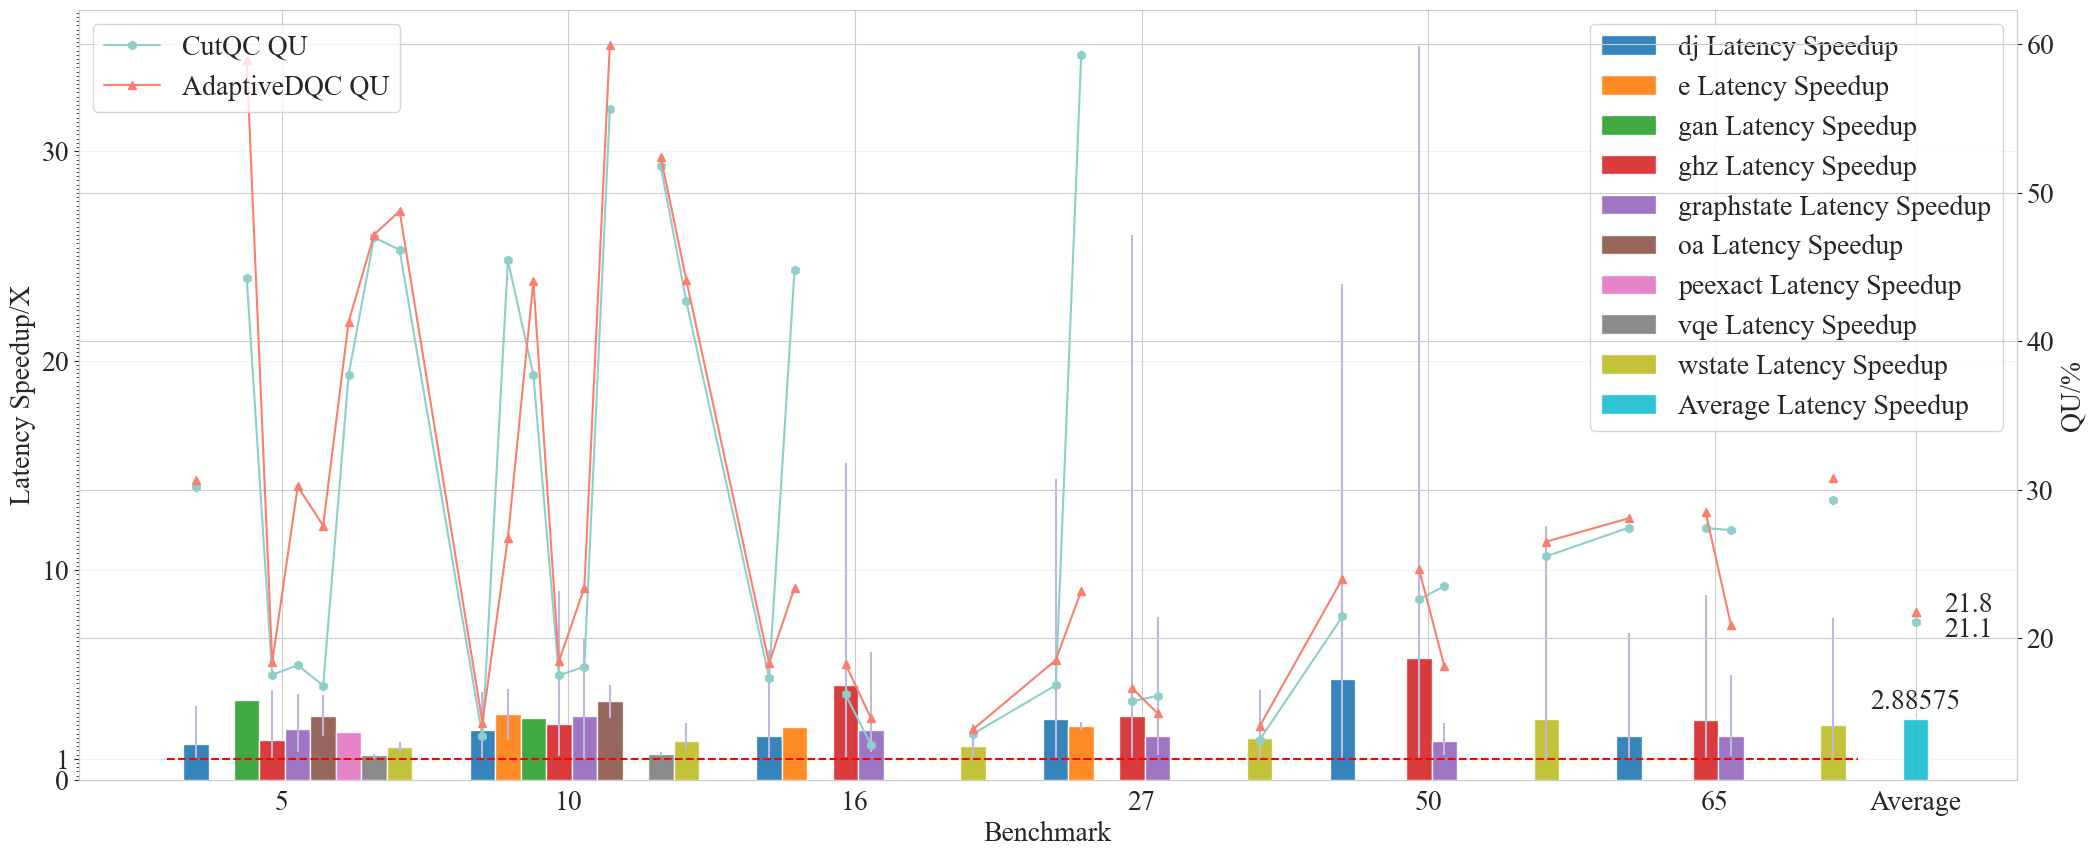

In [243]:
## 绘制Latency Speedup
import matplotlib.pyplot as plt
colours = ['#8ECFC9',
           "#FFBE7A",
           "#FA7F6F",
           "#82B0D2",
           "#BEB8DC",
           "#E7DAD2"]
## 字体大小设置
plt.rc('font', family='Times New Roman', size=20)
## 设置x轴刻度 按照qpu_width和 name 分组
names = latency_df['name'].value_counts().sort_index().index.to_list()
x_label= latency_df['qpu_width'].value_counts().sort_index().index.to_list()
fig = plt.figure(figsize=(25, 10))
ax1 = fig.add_subplot(111)
# ##设置x轴的位置刻度
x_index = np.arange(len(x_label))
width = 0.8/len(names)
data_mean = latency_df.groupby(by=['qpu_width', 'name']).mean()[['Latency_Speedup','mip_QU','basic_QU']].reset_index(level=1)
data_max = latency_df.groupby(by=['qpu_width', 'name']).max()[[
    'Latency_Speedup','mip_QU','basic_QU']].reset_index(level=1)
data_min = latency_df.groupby(by=['qpu_width', 'name']).min()[[
    'Latency_Speedup','mip_QU','basic_QU']].reset_index(level=1)
ax2 = ax1.twinx()  # this is the important function
for i in range(len(names)):
    d_min = data_min[data_min['name'] == names[i]][[
    'Latency_Speedup','mip_QU','basic_QU']]
    d_max = data_max[data_max['name'] == names[i]][[
        'Latency_Speedup','mip_QU','basic_QU']]
    d_mean = data_mean[data_mean['name'] == names[i]][[
        'Latency_Speedup','mip_QU','basic_QU']]
    d_max = d_max-d_mean
    d_min = d_mean-d_min
    d_mean = d_mean.reindex(x_label).sort_index()
    d_min = d_min.reindex(x_label).sort_index()
    d_max = d_max.reindex(x_label).sort_index()
    ax1.bar([x+width*i for x in x_index],d_mean['Latency_Speedup'],width=width,yerr=[d_min['Latency_Speedup'],d_max['Latency_Speedup']],ecolor=colours[4],label=names[i]+' Latency Speedup',alpha=0.9)
    # 绘制y=1的参考线
## 绘制平均值
all_mean = latency_df.mean()[['Latency_Speedup','mip_QU','basic_QU']]
rect = ax1.bar([len(x_label)],all_mean['Latency_Speedup'],width=width,label='Average Latency Speedup',alpha=0.9)
ax1.bar_label(rect, padding=3)
data_mean = data_mean.reset_index()
## 设置多维索引保证 QPU width 都有 [5,10,16,27,50,65]
## 构造 name 和QPU width 的多维索引
Mu_index = pd.MultiIndex.from_product(
    [x_label, names], names=['qpu_width', 'name'])
data_mean = data_mean.set_index(['qpu_width', 'name']).reindex(Mu_index).sort_index()
    ## 绘制QU折线图
Mu_xs = [xi+width*i for xi in x_index for i in range(len(names))]
ax2.scatter(Mu_xs,data_mean['mip_QU']*100,marker='h', label="CutQC QU", color=colours[0])
ax2.scatter(Mu_xs,data_mean['basic_QU']*100,marker='^',label="adaptivedqc QU",color=colours[2])
Avg_id = len(x_label)
Avg_data = [all_mean['mip_QU']*100,all_mean['basic_QU']*100]
ax2.scatter([Avg_id],Avg_data[0],marker='h',color=colours[0])
ax2.scatter([Avg_id],Avg_data[1],
            marker='^', color=colours[2])
ax2.annotate(f'{Avg_data[1]:.1f}', xy=(Avg_id,Avg_data[1]),
             xytext=(Avg_id+0.1, Avg_data[1]))
ax2.annotate(f'{Avg_data[0]:.1f}', xy=(Avg_id,Avg_data[0]),
             xytext=(Avg_id+0.1, Avg_data[0]-1))
ax1.hlines(1,x_index.min()-0.1,x_index.max()+0.8,color='red', linestyles='dashed')
ax1.legend(loc=1)
ax1.set_ylabel('Latency Speedup/X')
x_index = np.append(x_index+0.3,len(x_label))
x_label.append('Average')
ax1.set_xticks(x_index, labels=x_label)
## 设置y轴刻度并设为虚线
ax1.set_yticks([0,1,10,20,30])
ax1.grid(axis='y',linestyle='--',
            linewidth=0.5, color='gray', alpha=0.2)
ax1.minorticks_on()
ax2.legend(loc=2)
## 设置
ax2.set_ylabel('QU/%')
ax1.set_xlabel("Benchmark")
## 显示图形
plt.show()